# Custom Color Palettes in `geomImshow()`

The `cmap` parameter in `geomImshow()` controls how greyscale images are colorized. 

It accepts a `list` of color codes. When a `list` is provided, pixel values are binned across the given colors. For smoother gradients, you can use the `palette(n)` method on any color scale to generate a larger palette.


In [1]:
%useLatestDescriptors
%use lets-plot(output="png")

In [2]:
LetsPlot.getInfo()

Lets-Plot Kotlin API v.4.13.0. Frontend: Notebook with dynamically loaded JS. Lets-Plot JS v.4.9.0.
Outputs: Static PNG

In [3]:
import javax.imageio.ImageIO
import java.net.URL

// Load Mount Rainier shaded relief (georeferenced tiff).
// Source: https://pugetsoundlidar.ess.washington.edu/lidardata/restricted/filegeodatabase/mtrainierNP/index.html
val url = URL("https://github.com/JetBrains/lets-plot/raw/master/docs/f-26a/data/mount_rainier_shaded_relief.tif")
val bufferedImage = ImageIO.read(url)

// Take the Blue channel only
val w = bufferedImage.width
val h = bufferedImage.height
val argb = bufferedImage.getRGB(0, 0, w, h, null, 0, w)  // 0xAARRGGBB
val pixels = IntArray(w * h)
for (i in argb.indices) {
    pixels[i] = argb[i] and 0xFF  // BB bite only
}



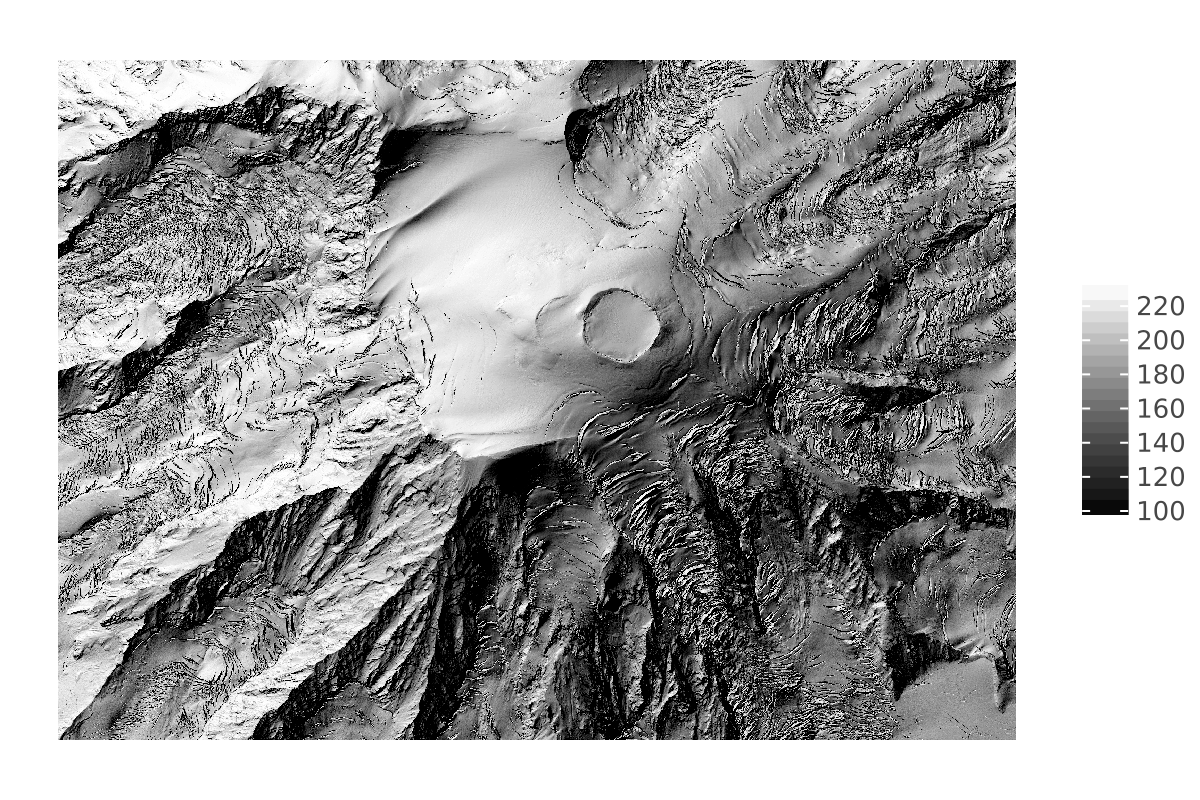

In [4]:
val rasterData = RasterData.create(pixels, w, h, 1)
letsPlot() + themeVoid() + geomImshow(
    rasterData, 
    vmin=100   // This is just to give the image a bit more contrast
)

#### Apply a Custom Palette


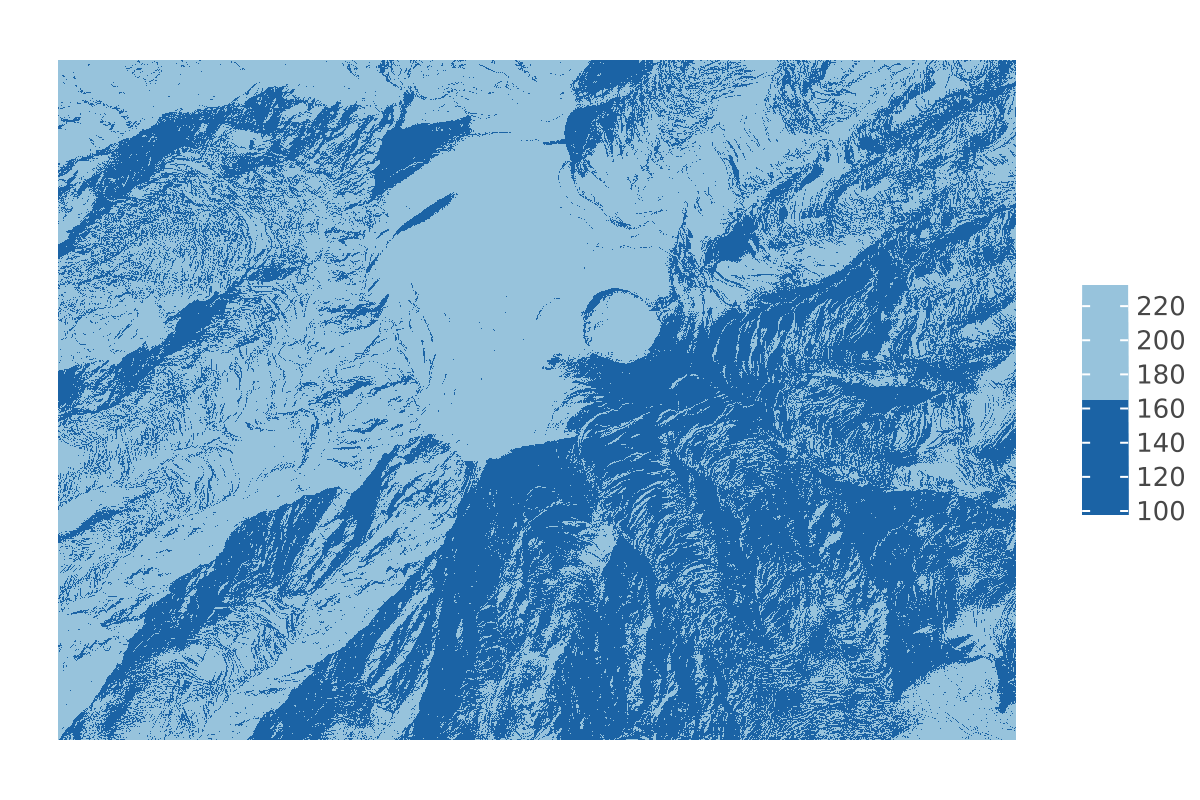

In [5]:
val blue1 = "#97C3DC"
val blue2 = "#1B63A5"

letsPlot() + themeVoid() + geomImshow(
    rasterData,
    vmin=100,
    cmap = listOf(blue2, blue1)    // <-- Use palette containing just two colors
)


#### Generate Palette Using `scale.palette(n)` 


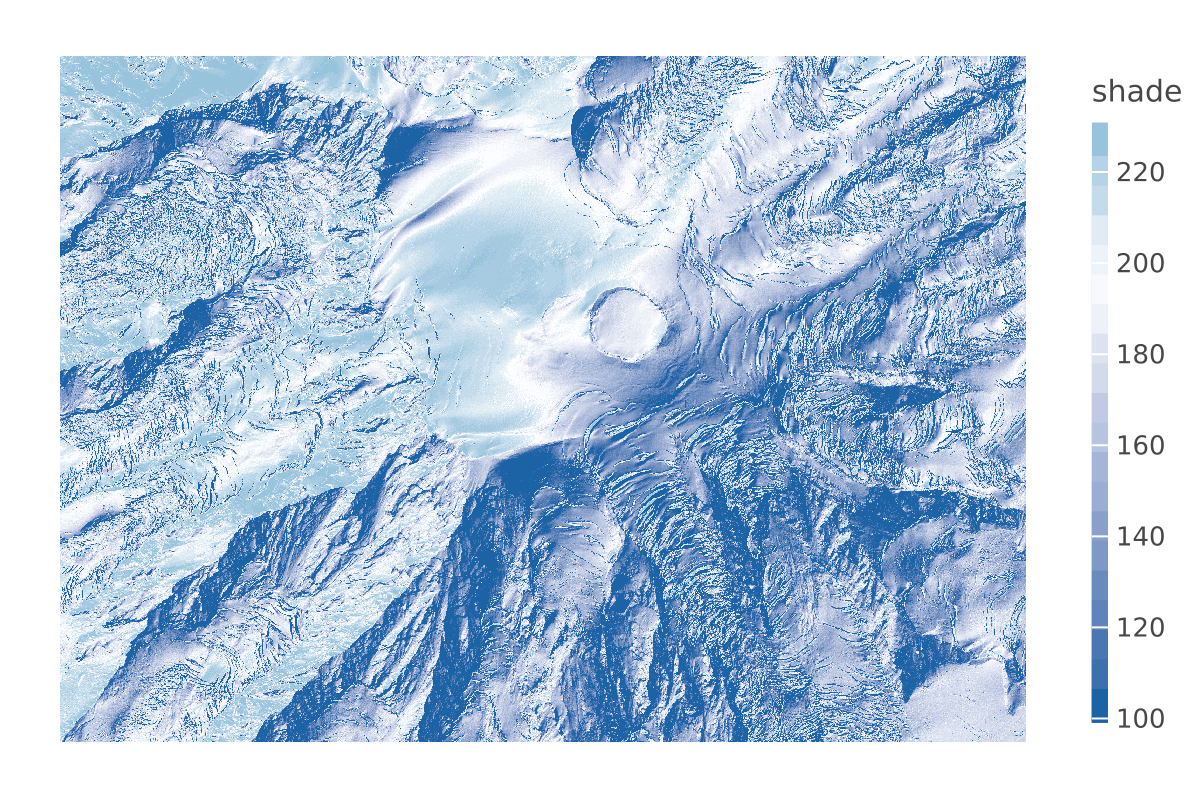

In [6]:
val palette = scaleColorGradient2(
    low = blue2,
    mid = "white",
    high = blue1,
    midpoint = 0.5    // <-- the midpoint should be in range -1..1 
).palette(30)         // <-- generate 30 colors

letsPlot() + themeVoid() + geomImshow(
    rasterData,
    vmin=100,
    cmap = palette,
    cguide = guideColorbar(  // <-- adjust the colorbar if needed
        title = "shade",
        barWidth = 8,
        barHeight = 300
    )
)
